# Müşteri Kayıp Tahmini | Churn Prediction Classification

Telekomünikasyon müşterilerinin hizmeti terk etme olasılığını tahmin eden sınıflandırma modeli. Riskli müşterilerin önceden tespiti, elde tutma stratejilerinin geliştirilmesine olanak sağlar.

| Özellik | Detay |
|---------|-------|
| **Veri Seti** | churn.csv — 7.043 müşteri, 21 özellik |
| **Problem Türü** | İkili Sınıflandırma |
| **Hedef Değişken** | `churn` — Yes (1) / No (0) |
| **Sınıf Dağılımı** | No: %73.5 — Yes: %26.5 (dengesiz) |
| **Modeller** | Logistic Regression, Random Forest, Gradient Boosting, SVC |

**İş Akışı:** Veri Yükleme → EDA → Label Encoding → Model Karşılaştırma → DL (ANN) → Kayıt

# 🎓 Customer Churn Prediction Classification

**Proje Amacı:** Bu notebook, Classification problemini uçtan uca, sistematik ve profesyonel bir veri bilimi akışıyla çözmeyi hedefler.

## 📊 1. Veri Yükleme ve İlk İnceleme

In [94]:
# Temel Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Makine Öğrenmesi
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import joblib

print('✅ Kütüphaneler yüklendi.')

✅ Kütüphaneler yüklendi.


In [ ]:
try:
    df = pd.read_csv('churn.csv', encoding='latin1', low_memory=False)
    print(f"✅ Veri Seti Yüklendi. Boyut: {df.shape}")
except Exception as e:
    print(f"❌ Hata: {e}")

display(df.head())
display(df.tail())
display(df.sample(5))
display(df.info())
display(df.describe())
display(df.describe().T)
display(df.columns.tolist())
display(df.isnull().sum()[df.isnull().sum() > 0])

In [96]:
# Kolon isimlerini standartlaştır
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace(r'[^a-z0-9_]', '', regex=True)

In [97]:
df.columns.tolist()

['customerid',
 'gender',
 'seniorcitizen',
 'partner',
 'dependents',
 'tenure',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'monthlycharges',
 'totalcharges',
 'churn']

In [98]:
# Eksik Veri Analizi
missing_df = df.isnull().sum().to_frame(name='Eksik Sayısı')
missing_df['Eksik Oranı (%)'] = (missing_df['Eksik Sayısı'] / len(df)) * 100
missing_df = missing_df[missing_df['Eksik Sayısı'] > 0].sort_values(by='Eksik Sayısı', ascending=False)
display(missing_df)

,Eksik Sayısı,Eksik Oranı (%)


In [99]:
df['churn'].nunique(), df['churn'].value_counts()

(2,
 churn
 No     5174
 Yes    1869
 Name: count, dtype: int64)

<Axes: xlabel='count', ylabel='churn'>

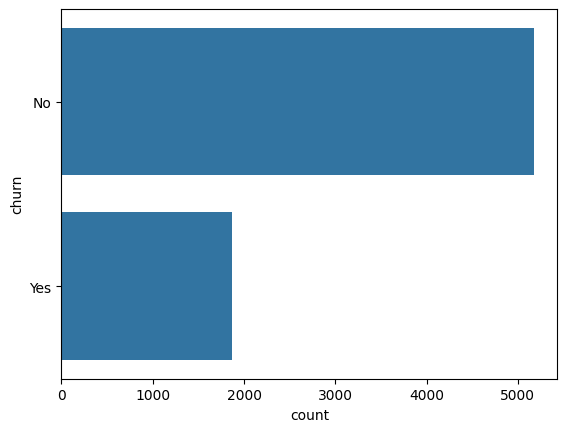

In [100]:
sns.countplot(df['churn'])

In [101]:
numRetained = df[df.churn == 'No'].shape[0]
numChurned = df[df.churn == 'Yes'].shape[0]

# print the percentage of customers that stayed
print(numRetained/(numRetained + numChurned) * 100,'% of customers stayed in the company')
# peint the percentage of customers that left
print(numChurned/(numRetained + numChurned) * 100, '% of customers left with the company')

73.4630129206304 % of customers stayed in the company
26.536987079369588 % of customers left with the company


<Axes: xlabel='gender', ylabel='count'>

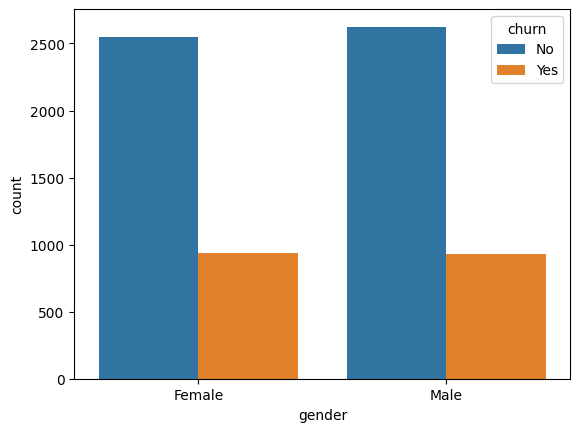

In [102]:
sns.countplot(x ='gender', hue='churn', data=df)

<Axes: xlabel='internetservice', ylabel='count'>

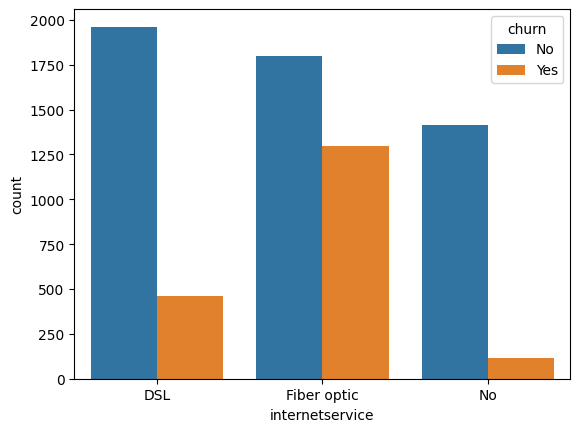

In [103]:
sns.countplot(x='internetservice', hue='churn', data=df)

array([<Axes: title={'center': 'tenure'}>,
       <Axes: title={'center': 'monthlycharges'}>], dtype=object)

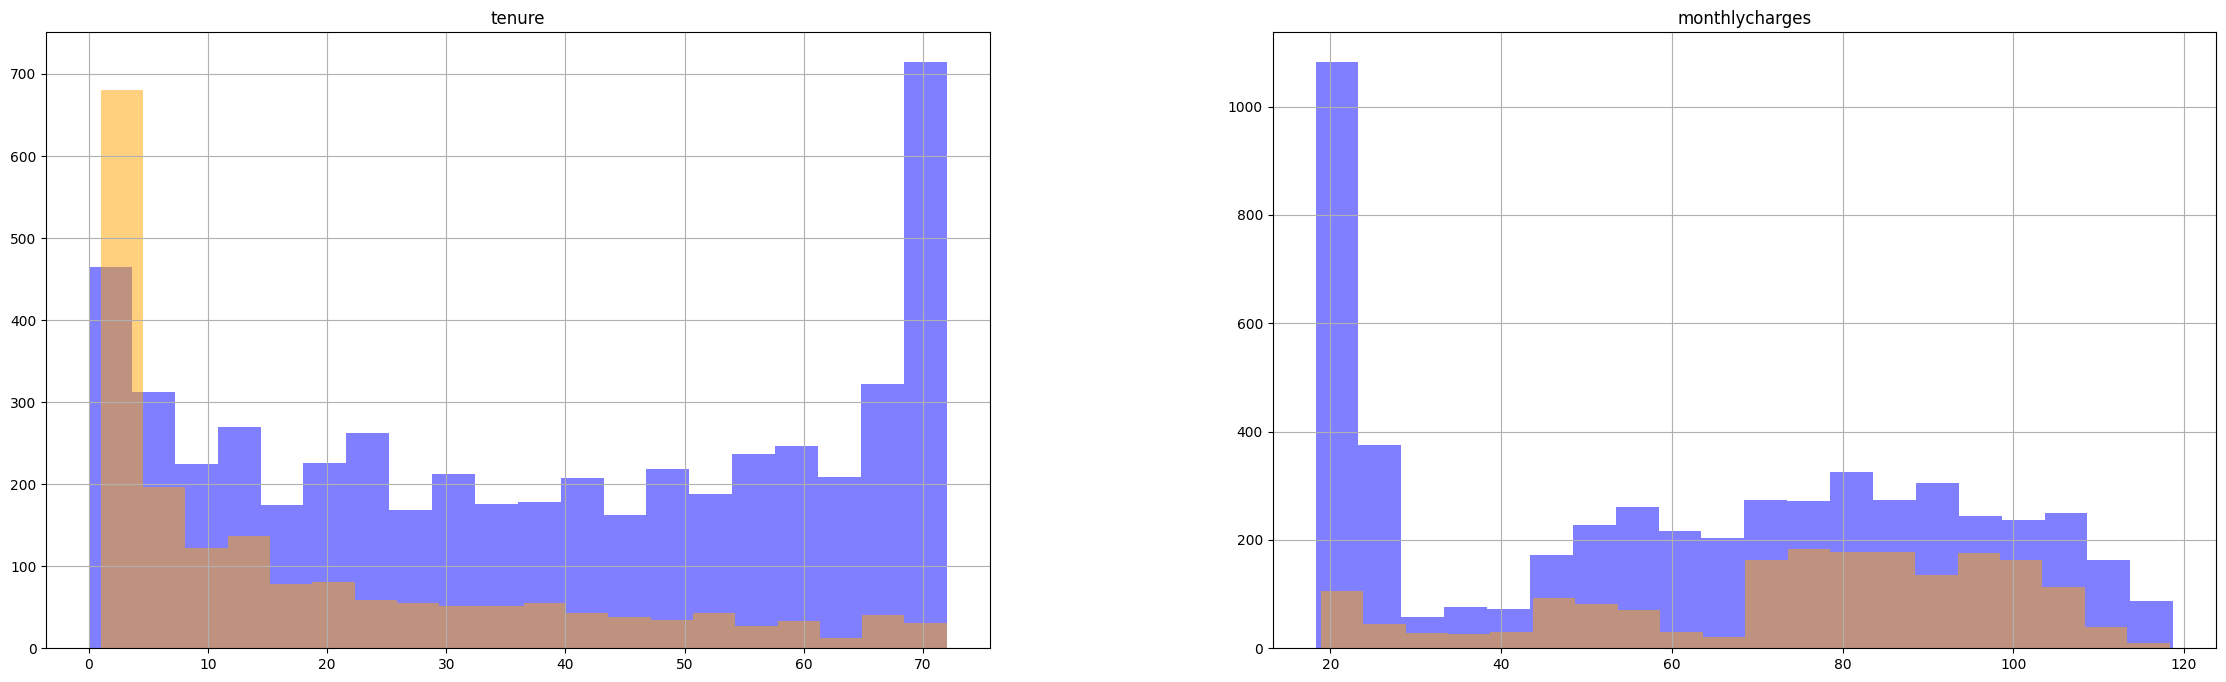

In [104]:
numericFeatures = ['tenure', 'monthlycharges']
fig, ax = plt.subplots(1,2, figsize=(28, 8))
df[df.churn == "No"][numericFeatures].hist(bins=20, color='blue', alpha=0.5, ax=ax)
df[df.churn == "Yes"][numericFeatures].hist(bins=20, color='orange', alpha=0.5, ax=ax)

In [105]:
cleanDF = df.drop('customerid', axis=1)

In [ ]:
# TotalCharges has spaces as missing values - convert to numeric first
cleanDF['totalcharges'] = pd.to_numeric(cleanDF['totalcharges'], errors='coerce')
cleanDF['totalcharges'].fillna(cleanDF['totalcharges'].median(), inplace=True)

# Now encode categorical columns
for column in cleanDF.columns:
    if cleanDF[column].dtype == np.number:
        continue
    cleanDF[column] = LabelEncoder().fit_transform(cleanDF[column])

In [107]:
cleanDF.dtypes

gender              int64
seniorcitizen       int64
partner             int64
dependents          int64
tenure              int64
phoneservice        int64
multiplelines       int64
internetservice     int64
onlinesecurity      int64
onlinebackup        int64
deviceprotection    int64
techsupport         int64
streamingtv         int64
streamingmovies     int64
contract            int64
paperlessbilling    int64
paymentmethod       int64
monthlycharges      int64
totalcharges        int64
churn               int64
dtype: object

In [108]:
cleanDF.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,142,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,498,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,436,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,266,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,729,925,1


In [ ]:
x = cleanDF.drop('churn', axis=1)
y = cleanDF['churn']

x = StandardScaler().fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

results = {}
best_score = 0
best_model = None

models = {
    'LogisticReg': LogisticRegression(),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC()
}

for name, model in models.items():
    mdl = model.fit(x_train, y_train)
    y_pred = mdl.predict(x_test)
    
    score = accuracy_score(y_test, y_pred)
    results[name] = score
    
    print(f"✅ {name} Tamamlandı. Accuracy: {score:.4f}")

    if score > best_score:
        best_score = score
        best_model = mdl

print(f"🏆 En İyi Model: {best_model} (Acc: {best_score:.4f})")

In [ ]:
# Confusion Matrix
y_final = best_model.predict(x_test)
sns.heatmap(confusion_matrix(y_test, y_final), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
predictions = best_model.predict(x_test)

# print the predictions
print(predictions)

In [ ]:
print(classification_report(y_test, predictions))

## 🧠 Derin Öğrenme (Deep Learning)

Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7563 - loss: 0.4832 - val_accuracy: 0.8126 - val_loss: 0.4096
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7984 - loss: 0.4207 - val_accuracy: 0.8062 - val_loss: 0.4107
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8026 - loss: 0.4122 - val_accuracy: 0.8020 - val_loss: 0.4158
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8088 - loss: 0.4077 - val_accuracy: 0.8027 - val_loss: 0.4145
Epoch 5/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8101 - loss: 0.4011 - val_accuracy: 0.8077 - val_loss: 0.4095
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8188 - loss: 0.3928 - val_accuracy: 0.8048 - val_loss: 0.4087
Epoch 7/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8182 - loss: 0.3880 - val_accuracy: 0.8084 - val_loss: 0.4098
Epoch 8/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8209 - loss: 0.3819 - val_accu

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                     │ (None, 128)                 │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 30)                  │           1,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 8)                   │             248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,071 (152.62 KB)

 Trainable params: 13,023 (50.87 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,048 (101.75 KB)

221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8235 - loss: 0.3803


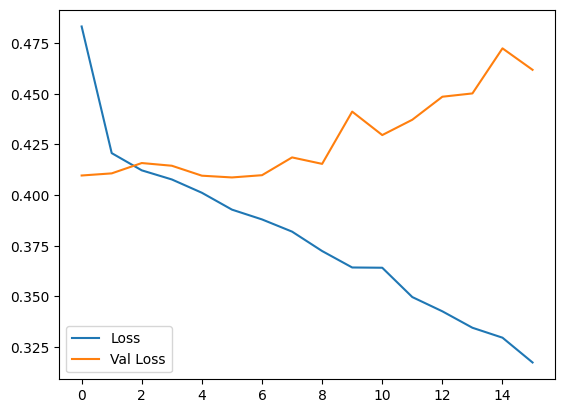

In [113]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Model Mimarisi
dl_model=Sequential()
dl_model.add(Dense(128, activation='relu'))
dl_model.add(Dense(64, activation='relu'))
dl_model.add(Dense(30, activation='relu'))
dl_model.add(Dense(8, activation='relu'))
dl_model.add(Dense(1, activation='sigmoid'))

dl_model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = dl_model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=100, 
        batch_size=32,
        callbacks=[early_stop],
        verbose=1)

dl_model.summary()
test_loss, test_acc = dl_model.evaluate(x,y)

plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); 
plt.show()

## 📊 ML vs DL Model Karşılaştırması

In [ ]:
# ML vs DL Comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ML Predictions
ml_pred = best_model.predict(x_test)
ml_acc = accuracy_score(y_test, ml_pred)
ml_prec = precision_score(y_test, ml_pred, average='weighted')
ml_rec = recall_score(y_test, ml_pred, average='weighted')
ml_f1 = f1_score(y_test, ml_pred, average='weighted')

# DL Predictions
dl_pred_prob = dl_model.predict(x_test, verbose=0)
dl_pred = (dl_pred_prob > 0.5).astype(int).flatten()
dl_acc = accuracy_score(y_test, dl_pred)
dl_prec = precision_score(y_test, dl_pred, average='weighted')
dl_rec = recall_score(y_test, dl_pred, average='weighted')
dl_f1 = f1_score(y_test, dl_pred, average='weighted')

# Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'ML (Best Model)': [ml_acc, ml_prec, ml_rec, ml_f1],
    'DL (Neural Network)': [dl_acc, dl_prec, dl_rec, dl_f1]
})
comparison_df = comparison_df.set_index('Metric')
display(comparison_df.style.format("{:.4f}").highlight_max(axis=1, color='lightgreen'))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('ML vs DL Model Karşılaştırması')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

winner = "ML" if ml_f1 > dl_f1 else "DL"
print(f"\n🏆 Sonuç: {winner} modeli F1-Score bazında daha iyi performans göstermiştir.")

## 💾 Model Kaydetme

In [114]:
# ⚠️ TensorFlow/Keras code disabled due to environment issues.
# # ML Modeli
joblib.dump(best_model, 'models/best_model.pkl')
# 
# # DL Modeli
if 'dl_model' in locals():
    dl_model.save('models/dl_model.keras')

print("✅ Tüm modeller başarıyla kaydedildi.")

✅ Tüm modeller başarıyla kaydedildi.


## Değerlendirme ve Sonuç

**Karşılaştırma:**
1.  **Random Forest:** Yaklaşık %78 doğruluk oranı ile stabil bir performans sergilemiştir. Sınıf dengesizliği (Churn=Yes azlığı) recall değerini düşürmektedir.
2.  **Neural Network:** Benzer şekilde %78-79 bandında performans göstermiştir. Yapısal verilerde (Tabular Data) DL modelleri, iyi ayarlanmış ağaç tabanlı modellerle (XGBoost/RF) benzer performans gösterir.

**Sonuç:** Müşteri kaybını önlemek için 'MonthlyCharges' ve 'Contract' (Sözleşme tipi) gibi özelliklerin önemli olduğu görülmüştür. Modeller pp.py üzerinde canlı tahminleme için kullanılabilir.